In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils.utils import compute_weighted_returns, portfolio_performance_summary, compute_probability_weighted_returns
from utils.two_state_hmm import *
from utils.cvxpy_portfolio import *
from utils.benchmark_portfolio import *
from utils.three_state_hmm import *
from utils.three_state_portfolio_utils import *

## Set Up DataFrames

In [2]:
insampleRet = pd.read_csv("data/etf_returns_insample.csv", index_col=0, parse_dates=True)
outsampleRet = pd.read_csv("data/etf_returns_outsample.csv", index_col=0, parse_dates=True)
prices = pd.read_csv("data/etf_prices.csv", index_col=0, parse_dates=True) 

In [3]:
insampleRet

,EFA,GLD,HYG,IWM,LQD,QQQ,SPY,TLT
Date,,,,,,,,
2007-04-12,0.006655,-0.001343,0.000671,0.006702,0.001503,0.007886,0.004434,0.000228
2007-04-13,0.003311,0.012609,-0.001821,0.006412,-0.001692,0.002018,0.004552,-0.003094
2007-04-16,0.010497,0.008221,-0.000384,0.013673,0.000847,0.009140,0.009451,0.005495
2007-04-17,0.000126,-0.005865,-0.000480,-0.003036,0.005436,0.002217,0.002655,0.005578
2007-04-18,-0.000377,0.005573,0.000289,-0.005854,0.000282,-0.003327,0.001222,0.004982
...,...,...,...,...,...,...,...,...
2018-12-24,-0.011708,0.010891,-0.007506,-0.019588,-0.002317,-0.025110,-0.026778,0.004958
2018-12-26,0.022938,-0.003004,0.016687,0.046943,-0.000803,0.060567,0.049290,-0.010774
2018-12-27,0.002916,0.007576,-0.000617,0.004160,0.000000,0.003862,0.007648,0.000166


In [4]:
outsampleRet

,EFA,GLD,HYG,IWM,LQD,QQQ,SPY,TLT
Date,,,,,,,,
2019-01-02,-0.002044,0.000660,-0.001357,0.005660,0.003098,0.004011,0.001040,0.005254
2019-01-03,-0.009076,0.009025,0.000494,-0.018059,0.000442,-0.033217,-0.024152,0.011315
2019-01-04,0.030161,-0.008119,0.016644,0.036673,-0.000619,0.041895,0.032947,-0.011643
2019-01-07,0.003832,0.003453,0.009664,0.017342,0.000089,0.011835,0.007854,-0.002952
2019-01-08,0.006464,-0.002712,0.006470,0.015215,0.002207,0.009005,0.009351,-0.002632
...,...,...,...,...,...,...,...,...
2024-12-23,0.006503,-0.004720,-0.002676,-0.002301,-0.002902,0.009695,0.005970,-0.009215
2024-12-24,0.003566,0.001990,0.003185,0.008903,0.003089,0.013469,0.011054,0.004220
2024-12-26,0.004734,0.006728,0.002541,0.010199,0.000934,-0.000680,0.000067,-0.000569


In [5]:
prices

,EFA,GLD,HYG,IWM,LQD,QQQ,SPY,TLT
Date,,,,,,,,
2007-04-11,44.219479,67.080002,32.021992,62.195061,50.453194,37.935265,101.382843,48.607006
2007-04-12,44.514740,66.989998,32.043472,62.613289,50.529099,38.235615,101.833389,48.618099
2007-04-13,44.662357,67.839996,31.985174,63.016041,50.443672,38.312836,102.297989,48.467922
2007-04-16,45.133625,68.400002,31.972891,63.883572,50.486397,38.664623,103.269440,48.734982
2007-04-17,45.139305,68.000000,31.957541,63.689892,50.761600,38.750446,103.544014,49.007565
...,...,...,...,...,...,...,...,...
2024-12-23,72.980751,240.960007,72.909065,218.558975,100.825233,519.576416,586.186646,82.844894
2024-12-24,73.241432,241.440002,73.141632,220.513489,101.137184,526.621826,592.702087,83.195229
2024-12-26,73.589012,243.070007,73.327713,222.773987,101.231682,526.264038,592.741577,83.147881


## Fit Two-State HMM on SPY

In [6]:
regimeRetIn = insampleRet[["SPY"]]
model, stateDf = fit_two_state_hmm(regimeRetIn)
stateDf, stateMap = relabel_states_by_vol_two_state(stateDf)
summary = summarize_states(model, stateDf)

print("\nMeans learned by model:")
print(model.means_)

print("\nCovariances learned by model:")
print(model.covars_)

print("\nTransition matrix:")
print(model.transmat_)

print("\nState summary:")
print(summary)

plot_regimes(stateDf, output_dir="results", plot_id="insample_two_state_base")

Model is not converging.  Current: 9467.347159764715 is not greater than 9467.527147615903. Delta is -0.17998785118834348



Means learned by model:
[[ 0.00086539]
 [-0.00162136]]

Covariances learned by model:
[[[5.51659038e-05]]

 [[5.02319659e-04]]]

Transition matrix:
[[0.98760041 0.01239959]
 [0.03854429 0.96145571]]

State summary:
   state  n_obs  fraction  mean_return  volatility  annualized_mean_approx  \
0      0   2273  0.769986     0.000848    0.007252                0.213626   
1      1    679  0.230014    -0.001669    0.022396               -0.420668   

   annualized_vol_approx  
0               0.115128  
1               0.355519  


Try to fit another time here with standardization to see if convergence warning can be resolved

In [7]:
modelScaled, stateDfScaled, scaler = fit_two_state_hmm_scaled(regimeRetIn)
stateDfScaled, stateMapScaled = relabel_states_by_vol_two_state(stateDfScaled)
summaryScaled = summarize_states(modelScaled, stateDfScaled)

print("\nMeans learned by model (Scaled):")
print(modelScaled.means_)

print("\nCovariances learned by model (Scaled):")
print(modelScaled.covars_)

print("\nTransition matrix:")
print(modelScaled.transmat_)

print("\nState summary:")
print(summaryScaled)

plot_regimes(stateDfScaled, output_dir="results", plot_id="scaled")


Means learned by model (Scaled):
[[ 0.05983889]
 [-0.13101423]]

Covariances learned by model (Scaled):
[[[0.25765784]]

 [[2.60033778]]]

Transition matrix:
[[0.97801908 0.02198092]
 [0.04757044 0.95242956]]

State summary:
   state  n_obs  fraction  mean_return  volatility  annualized_mean_approx  \
0      0   2050  0.694444     0.000949    0.006426                0.239108   
1      1    902  0.305556    -0.001277    0.020406               -0.321766   

   annualized_vol_approx  
0               0.102006  
1               0.323929  


Convergence issue seems to be fixed with standardization, will be using scaled model from this point onward. Visually, there doesn't seem to be much difference, but the calculated values are slightly different.

### Display Intermediate Results

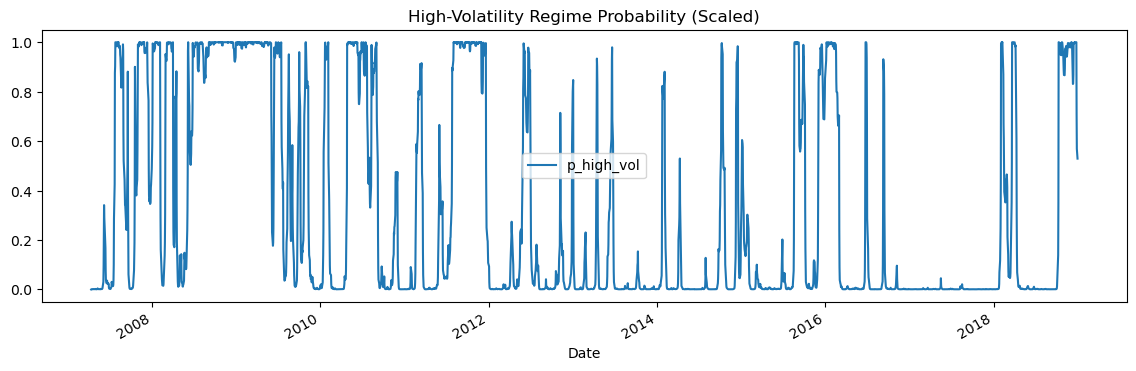

In [8]:
stateDfScaled[["p_high_vol"]].plot(figsize=(14, 4), title="High-Volatility Regime Probability (Scaled)")
plt.show()

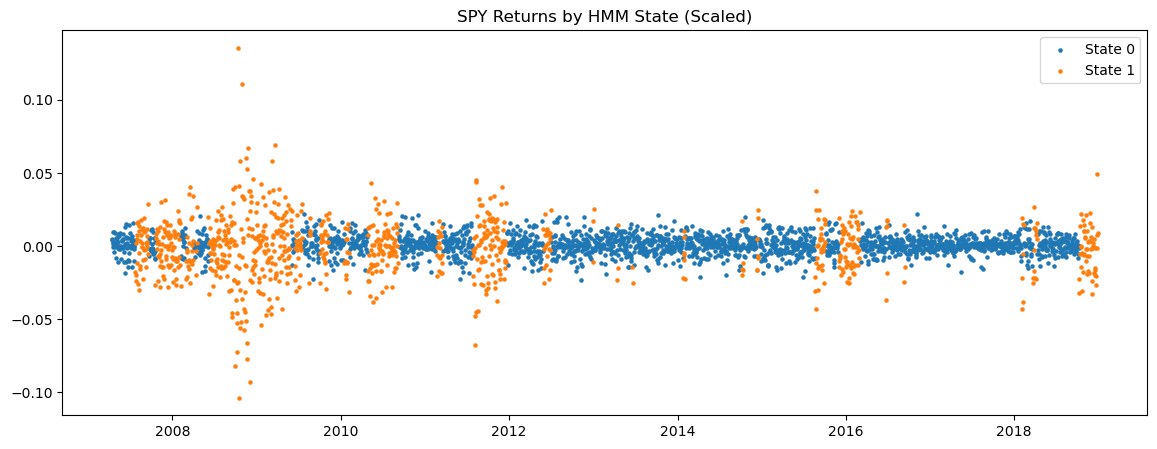

In [9]:
plt.figure(figsize=(14, 5))
for s in [0, 1]:
    mask = stateDfScaled["state"] == s
    plt.scatter(
        stateDfScaled.index[mask],
        stateDfScaled.loc[mask, "SPY_ret"],
        s=5,
        label=f"State {s}"
    )
plt.legend()
plt.title("SPY Returns by HMM State (Scaled)")
plt.show()

Checking 2008-2009 period to see if majority is truly classified as high-volatility, as we would expect.

In [10]:
stateDfScaled.loc["2008-01-01":"2009-06-30", ["SPY_ret", "state", "p_high_vol"]]

,SPY_ret,state,p_high_vol
Date,,,
2008-01-02,-0.008793,1,0.579020
2008-01-03,-0.000483,1,0.676568
2008-01-04,-0.024812,1,0.995013
2008-01-07,-0.000849,1,0.986133
2008-01-08,-0.016280,1,0.989315
...,...,...,...
2009-06-24,0.008581,1,0.983093
2009-06-25,0.021516,1,0.990555
2009-06-26,-0.002610,1,0.960123


In [11]:
stateDfScaled.loc["2008-01-01":"2009-06-30", ["state"]].value_counts()

state
1        312
0         65
Name: count, dtype: int64

## Label ETFs and Report Regime Metrics

In [12]:
#State 0: lower volatility, State 1: higher volatility
regimeLabels = stateDfScaled[["state"]].copy()
inRetLabeled = insampleRet.join(regimeLabels, how="inner")

display(inRetLabeled.head())

,EFA,GLD,HYG,IWM,LQD,QQQ,SPY,TLT,state
Date,,,,,,,,,
2007-04-12,0.006655,-0.001343,0.000671,0.006702,0.001503,0.007886,0.004434,0.000228,0
2007-04-13,0.003311,0.012609,-0.001821,0.006412,-0.001692,0.002018,0.004552,-0.003094,0
2007-04-16,0.010497,0.008221,-0.000384,0.013673,0.000847,0.009140,0.009451,0.005495,0
2007-04-17,0.000126,-0.005865,-0.000480,-0.003036,0.005436,0.002217,0.002655,0.005578,0
2007-04-18,-0.000377,0.005573,0.000289,-0.005854,0.000282,-0.003327,0.001222,0.004982,0


In [13]:
assetCols = [c for c in inRetLabeled.columns if c != "state"]

retRegime0 = inRetLabeled.loc[inRetLabeled["state"] == 0, assetCols].copy()
retRegime1 = inRetLabeled.loc[inRetLabeled["state"] == 1, assetCols].copy()

print("Regime 0 returns shape:", retRegime0.shape)
print("Regime 1 returns shape:", retRegime1.shape)

Regime 0 returns shape: (2050, 8)
Regime 1 returns shape: (902, 8)


In [14]:
cov0 = retRegime0.cov()
cov1 = retRegime1.cov()

In [15]:
cov0

,EFA,GLD,HYG,IWM,LQD,QQQ,SPY,TLT
EFA,7.328131e-05,0.000017,0.000017,0.000055,-2.768372e-08,0.000046,0.000045,-0.000018
GLD,1.696333e-05,0.000087,0.000003,0.000005,6.852851e-06,0.000002,0.000004,0.000012
HYG,1.704884e-05,0.000003,0.000013,0.000017,2.452939e-06,0.000014,0.000014,-0.000002
IWM,5.456937e-05,0.000005,0.000017,0.000084,-3.025019e-06,0.000055,0.000050,-0.000022
LQD,-2.768372e-08,0.000007,0.000002,-0.000003,1.088740e-05,-0.000001,-0.000002,0.000021
QQQ,4.626719e-05,0.000002,0.000014,0.000055,-1.132504e-06,0.000064,0.000045,-0.000016
SPY,4.495009e-05,0.000004,0.000014,0.000050,-1.628672e-06,0.000045,0.000041,-0.000016
TLT,-1.792763e-05,0.000012,-0.000002,-0.000022,2.082277e-05,-0.000016,-0.000016,0.000061


In [16]:
cov1

,EFA,GLD,HYG,IWM,LQD,QQQ,SPY,TLT
EFA,0.000552,2.930256e-05,0.000189,0.000497,3.819741e-05,0.000424,0.000448,-0.000141
GLD,0.000029,2.445389e-04,-0.000010,-0.000002,-8.266593e-07,-0.000007,0.000003,0.000016
HYG,0.000189,-1.036433e-05,0.000153,0.000179,4.291958e-05,0.000150,0.000165,-0.000052
IWM,0.000497,-1.773739e-06,0.000179,0.000593,1.857838e-05,0.000454,0.000464,-0.000149
LQD,0.000038,-8.266593e-07,0.000043,0.000019,6.410277e-05,0.000018,0.000025,0.000020
QQQ,0.000424,-6.566673e-06,0.000150,0.000454,1.775295e-05,0.000431,0.000396,-0.000121
SPY,0.000448,2.529022e-06,0.000165,0.000464,2.549308e-05,0.000396,0.000416,-0.000124
TLT,-0.000141,1.588819e-05,-0.000052,-0.000149,1.998561e-05,-0.000121,-0.000124,0.000134


In [17]:
summary0 = pd.DataFrame({
    "mean_daily": retRegime0.mean(),
    "vol_daily": retRegime0.std(),
    "mean_annual_approx": retRegime0.mean() * 252,
    "vol_annual_approx": retRegime0.std() * np.sqrt(252),
})

summary1 = pd.DataFrame({
    "mean_daily": retRegime1.mean(),
    "vol_daily": retRegime1.std(),
    "mean_annual_approx": retRegime1.mean() * 252,
    "vol_annual_approx": retRegime1.std() * np.sqrt(252),
})

display(summary0)
display(summary1)

,mean_daily,vol_daily,mean_annual_approx,vol_annual_approx
EFA,0.000766,0.008560,0.193120,0.135893
GLD,0.000067,0.009338,0.016830,0.148235
HYG,0.000358,0.003622,0.090222,0.057505
IWM,0.001068,0.009159,0.269047,0.145395
LQD,0.000175,0.003300,0.044078,0.052380
QQQ,0.001254,0.007998,0.316073,0.126958
SPY,0.000949,0.006426,0.239108,0.102006
TLT,-0.000049,0.007816,-0.012414,0.124071


,mean_daily,vol_daily,mean_annual_approx,vol_annual_approx
EFA,-0.001661,0.023493,-0.418525,0.372932
GLD,0.000504,0.015638,0.127133,0.248241
HYG,-0.000210,0.012384,-0.052945,0.196585
IWM,-0.001677,0.024348,-0.422591,0.386508
LQD,0.000209,0.008006,0.052743,0.127098
QQQ,-0.001345,0.020758,-0.339064,0.329526
SPY,-0.001277,0.020406,-0.321766,0.323929
TLT,0.000900,0.011579,0.226738,0.183813


## Portfolio Construction

In [18]:
inRegimeWeights0 = solve_min_variance_portfolio(cov0)
inRegimeWeights1 = solve_min_variance_portfolio(cov1)

print("Regime 0 weights:")
print(inRegimeWeights0.sort_values(ascending=False))

print("\nRegime 1 weights:")
print(inRegimeWeights1.sort_values(ascending=False))

Set parameter Username
Set parameter LicenseID to value 2768137
Academic license - for non-commercial use only - expires 2027-01-21
Regime 0 weights:
LQD    5.600737e-01
HYG    3.424800e-01
SPY    7.580707e-02
GLD    2.162792e-02
QQQ    6.870629e-06
IWM    3.792282e-06
TLT    3.444800e-07
EFA    3.038030e-07
dtype: float64

Regime 1 weights:
TLT    3.519531e-01
LQD    2.630121e-01
HYG    1.555059e-01
GLD    1.198165e-01
QQQ    9.088746e-02
IWM    1.880084e-02
SPY    2.404929e-05
EFA    8.911121e-08
dtype: float64


In [19]:
inWeightsDf = pd.DataFrame({
    "Regime_0": inRegimeWeights0,
    "Regime_1": inRegimeWeights1
})

inWeightsDf

,Regime_0,Regime_1
EFA,3.038030e-07,8.911121e-08
GLD,2.162792e-02,1.198165e-01
HYG,3.424800e-01,1.555059e-01
IWM,3.792282e-06,1.880084e-02
LQD,5.600737e-01,2.630121e-01
QQQ,6.870629e-06,9.088746e-02
SPY,7.580707e-02,2.404929e-05
TLT,3.444800e-07,3.519531e-01


<Axes: title={'center': 'Portfolio Weights by Regime (Min-Var)'}>

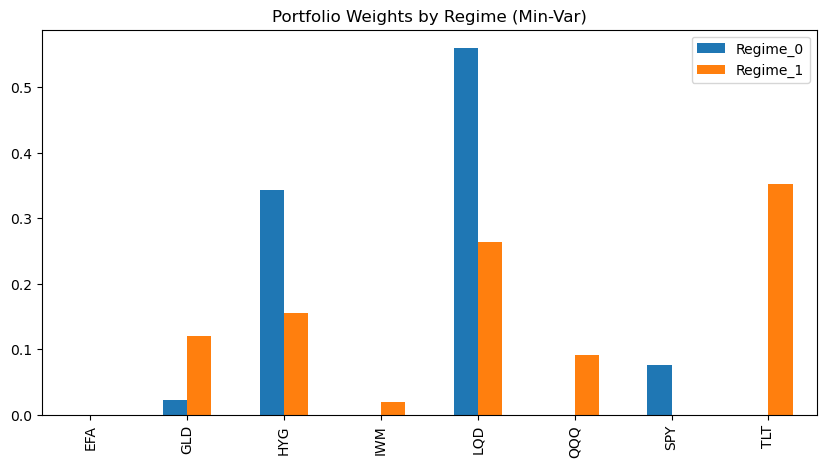

In [20]:
inWeightsDf.plot(kind="bar", figsize=(10, 5), title="Portfolio Weights by Regime (Min-Var)")

In [21]:
inPortStats0 = portfolio_stats(inRegimeWeights0, retRegime0)
inPortStats1 = portfolio_stats(inRegimeWeights1, retRegime1)

statsDf = pd.DataFrame({
    "Regime_0": inPortStats0,
    "Regime_1": inPortStats1
})
statsDf

,Regime_0,Regime_1
mean_daily,0.000294,0.000246
vol_daily,0.002639,0.005695
mean_annual_approx,0.074079,0.061903
vol_annual_approx,0.041888,0.090405
sharpe_approx,1.768528,0.684734


In [22]:
inRegimeMeanVarWeights0 = solve_mean_variance_portfolio(retRegime0.mean(), cov0)
inRegimeMeanVarWeights1 = solve_mean_variance_portfolio(retRegime1.mean(), cov1)

inWeightsMeanVarDf = pd.DataFrame({
    "Regime_0": inRegimeMeanVarWeights0,
    "Regime_1": inRegimeWeights1
})

inWeightsMeanVarDf

,Regime_0,Regime_1
EFA,1.507991e-22,8.911121e-08
GLD,3.710746e-23,1.198165e-01
HYG,3.591380e-23,1.555059e-01
IWM,9.435379e-24,1.880084e-02
LQD,1.424279e-02,2.630121e-01
QQQ,5.000000e-01,9.088746e-02
SPY,4.258340e-01,2.404929e-05
TLT,5.992325e-02,3.519531e-01


<Axes: title={'center': 'Portfolio Weights by Regime (Mean-Variance)'}>

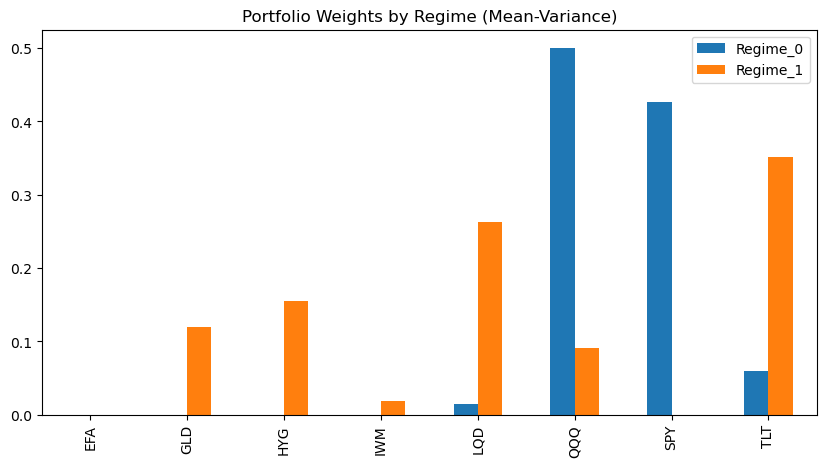

In [23]:
inWeightsMeanVarDf.plot(kind="bar", figsize=(10, 5), title="Portfolio Weights by Regime (Mean-Variance)")

In [24]:
inPortStatsMeanVar0 = portfolio_stats(inRegimeMeanVarWeights0, retRegime0)
inPortStatsMeanVar1 = portfolio_stats(inRegimeMeanVarWeights1, retRegime1)

statsMeanVarDf = pd.DataFrame({
    "Regime_0": inPortStatsMeanVar0,
    "Regime_1": inPortStatsMeanVar1
})
statsMeanVarDf

,Regime_0,Regime_1
mean_daily,0.001031,0.000521
vol_daily,0.006392,0.006635
mean_annual_approx,0.259741,0.131409
vol_annual_approx,0.101478,0.105334
sharpe_approx,2.559588,1.247556


## Backtesting (Mean-Variance)

In [25]:
# modelScaled is fitted model on insample data, scaler is the fitted scaler on insample data, outsampleRet[["SPY"]] is the SPY returns from outsample data
# stateMapScaled is the mapping from raw state labels to volatility-based state labels learned from insample data, returned above
outsampleStateRaw = classify_outsample_two_state(modelScaled, scaler, outsampleRet[["SPY"]])
outsampleState = apply_state_map(outsampleStateRaw, stateMapScaled)

outsampleState.head()

,SPY_ret,state_raw,p_state_0,p_state_1,state,p_low_vol,p_high_vol
Date,,,,,,,
2019-01-02,0.001040,0,1.000000,5.972685e-39,0,1.000000,5.972685e-39
2019-01-03,-0.024152,1,0.002469,9.975311e-01,1,0.002469,9.975311e-01
2019-01-04,0.032947,1,0.000073,9.999267e-01,1,0.000073,9.999267e-01
2019-01-07,0.007854,0,0.506566,4.934344e-01,0,0.506566,4.934344e-01
2019-01-08,0.009351,0,0.755125,2.448754e-01,0,0.755125,2.448754e-01


In [26]:
outsampleState["state"].value_counts()

state
0    1004
1     505
Name: count, dtype: int64

<Axes: title={'center': 'Out-of-Sample High-Vol Probability'}, xlabel='Date'>

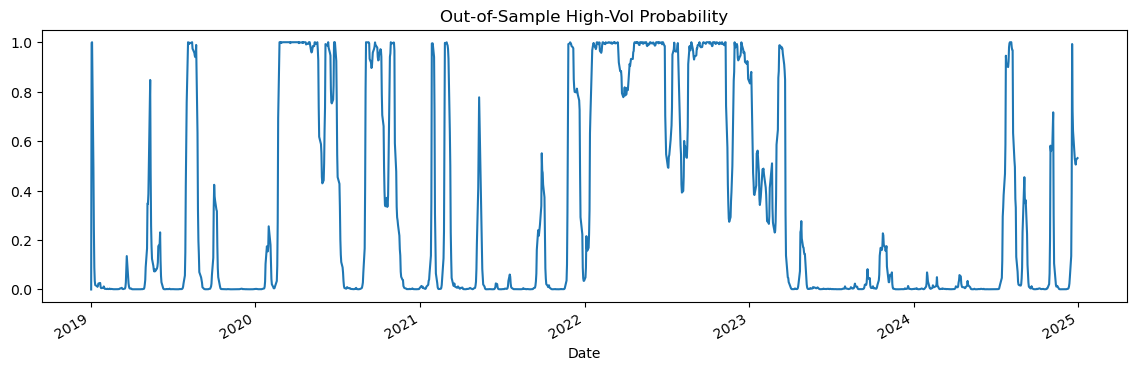

In [27]:
outsampleState["p_high_vol"].plot(figsize=(14,4), title="Out-of-Sample High-Vol Probability")

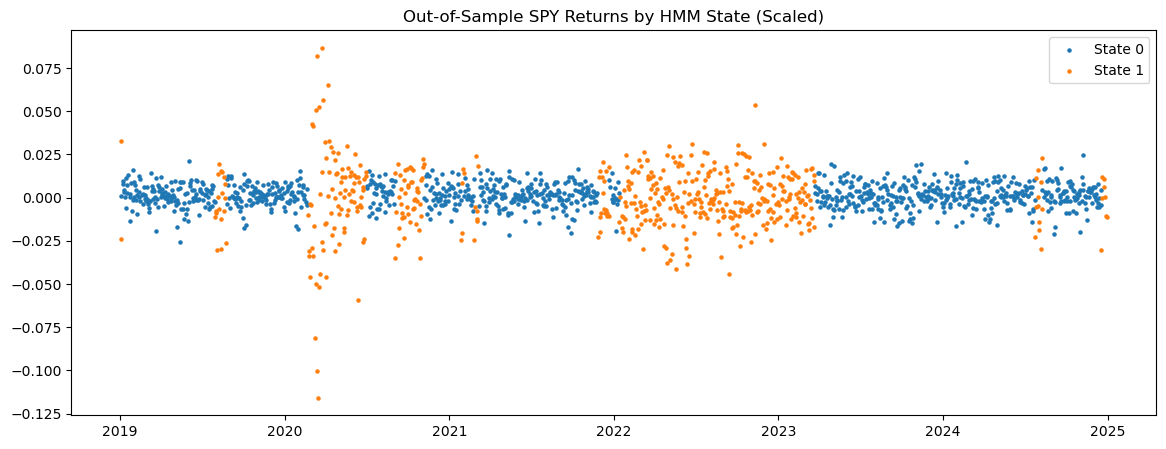

In [28]:
plt.figure(figsize=(14, 5))
for s in [0, 1]:
    mask = outsampleState["state"] == s
    plt.scatter(
        outsampleState.index[mask],
        outsampleState.loc[mask, "SPY_ret"],
        s=5,
        label=f"State {s}"
    )
plt.legend()
plt.title("Out-of-Sample SPY Returns by HMM State (Scaled)")
plt.show()

In [29]:
# Checking COVID period
outsampleState.loc["2020-02-01":"2020-06-30", ["SPY_ret", "state", "p_high_vol"]]

,SPY_ret,state,p_high_vol
Date,,,
2020-02-03,0.007401,0,0.201222
2020-02-04,0.015126,0,0.180519
2020-02-05,0.011482,0,0.111297
2020-02-06,0.003359,0,0.042492
2020-02-07,-0.005344,0,0.021002
...,...,...,...
2020-06-24,-0.025840,1,0.999612
2020-06-25,0.010663,1,0.998147
2020-06-26,-0.024038,1,0.999525


In [30]:
# COVID period state counts
outsampleState.loc["2020-02-01":"2020-06-30", ["state"]].value_counts()

state
1        91
0        13
Name: count, dtype: int64

In [31]:
outsampleRetRegime = outsampleRet.join(outsampleState[["state"]], how="inner")

outsampleRetRegime

,EFA,GLD,HYG,IWM,LQD,QQQ,SPY,TLT,state
Date,,,,,,,,,
2019-01-02,-0.002044,0.000660,-0.001357,0.005660,0.003098,0.004011,0.001040,0.005254,0
2019-01-03,-0.009076,0.009025,0.000494,-0.018059,0.000442,-0.033217,-0.024152,0.011315,1
2019-01-04,0.030161,-0.008119,0.016644,0.036673,-0.000619,0.041895,0.032947,-0.011643,1
2019-01-07,0.003832,0.003453,0.009664,0.017342,0.000089,0.011835,0.007854,-0.002952,0
2019-01-08,0.006464,-0.002712,0.006470,0.015215,0.002207,0.009005,0.009351,-0.002632,0
...,...,...,...,...,...,...,...,...,...
2024-12-23,0.006503,-0.004720,-0.002676,-0.002301,-0.002902,0.009695,0.005970,-0.009215,1
2024-12-24,0.003566,0.001990,0.003185,0.008903,0.003089,0.013469,0.011054,0.004220,1
2024-12-26,0.004734,0.006728,0.002541,0.010199,0.000934,-0.000680,0.000067,-0.000569,1


In [32]:
regimeRetOut = compute_weighted_returns(outsampleRet,outsampleState["state"], inRegimeMeanVarWeights0, inRegimeMeanVarWeights1)

regimeRetOut

,state,portfolio_return
date,,
2019-01-02,0,0.002807
2019-01-03,1,0.007166
2019-01-04,1,-0.004110
2019-01-07,0,0.009086
2019-01-08,0,0.008358
...,...,...
2024-12-23,1,-0.006277
2024-12-24,1,0.003501
2024-12-26,1,0.001362


In [33]:
# Create mean-variance benchmark portfolio using full insample returns (not regime-specific)
cov_insample = insampleRet.cov()
mu_insample = insampleRet.mean()

staticWeights = solve_mean_variance_portfolio(mu_insample, cov_insample, max_weight=0.5)
staticWeights

EFA    5.849964e-23
GLD    9.403409e-02
HYG    1.076638e-01
IWM   -2.684800e-24
LQD    2.907700e-01
QQQ    2.125073e-01
SPY    3.044437e-23
TLT    2.950247e-01
Name: weight, dtype: float64

In [34]:
equallyWeighted = equal_weight_returns(outsampleRet)
staticWeighted = fixed_weight_returns(outsampleRet, staticWeights, name="static_portfolio")
regimeWeighted = regimeRetOut["portfolio_return"].rename("regime_switching")

In [35]:
backtestDf = pd.concat([regimeWeighted, equallyWeighted, staticWeighted], axis=1).dropna()
backtestDf

,regime_switching,equal_weight,static_portfolio
2019-01-02,0.002807,0.002040,0.003219
2019-01-03,0.007166,-0.007903,-0.002690
2019-01-04,-0.004110,0.017243,0.006317
2019-01-07,0.009086,0.006389,0.003035
2019-01-08,0.008358,0.005421,0.002220
...,...,...,...
2024-12-23,-0.006277,0.000044,-0.002234
2024-12-24,0.003501,0.006184,0.005535
2024-12-26,0.001362,0.002994,0.000865
2024-12-27,-0.006478,-0.007858,-0.007515


<Axes: title={'center': 'Out-of-Sample Cumulative Performance'}>

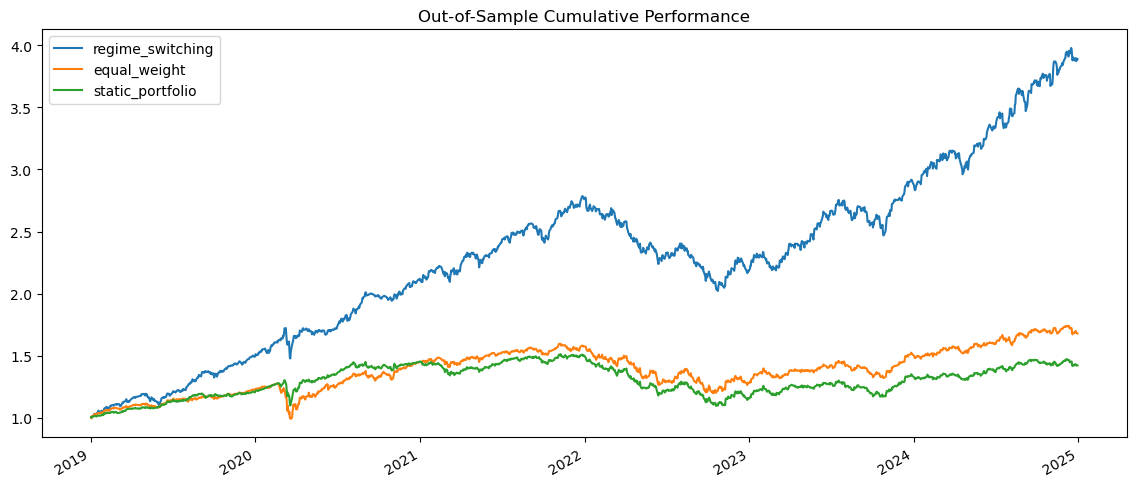

In [36]:
cumulativeDf = np.exp(backtestDf.cumsum())
cumulativeDf.plot(figsize=(14,6), title="Out-of-Sample Cumulative Performance")

In [37]:
performanceSummary = pd.DataFrame({
    "Regime Switching": portfolio_performance_summary(backtestDf["regime_switching"]),
    "Equal Weight": portfolio_performance_summary(backtestDf["equal_weight"]),
    "Static Portfolio": portfolio_performance_summary(backtestDf["static_portfolio"])
})

performanceSummary = performanceSummary.T
performanceSummary

,mean_daily,vol_daily,annualized_return_approx,annualized_vol_approx,sharpe_approx,max_drawdown,total_return
Regime Switching,0.000900,0.008186,0.226828,0.129943,1.745603,-0.274275,2.889451
Equal Weight,0.000343,0.007975,0.086511,0.126605,0.683310,-0.250046,0.678723
Static Portfolio,0.000233,0.006631,0.058706,0.105260,0.557721,-0.275266,0.421250


In [38]:
regimeRetOut["state_change"] = regimeRetOut["state"].diff().ne(0).astype(int)
n_switches = regimeRetOut["state_change"].sum()
print("Number of regime switches:", n_switches)

Number of regime switches: 20


### Implement One-Day Lag to Prevent Look-Ahead Bias

In [39]:
laggedStates = regimeRetOut["state"].shift(1).dropna()
outsampleRetLagged = outsampleRet.loc[laggedStates.index]
regimeRetOutLagged = compute_weighted_returns(outsampleRetLagged, laggedStates, inRegimeMeanVarWeights0, inRegimeMeanVarWeights1)

regimeWeightedLagged = regimeRetOutLagged["portfolio_return"].rename("regime_switching_lagged")

In [40]:
equallyWeightedLagged = equallyWeighted.loc[regimeRetOutLagged.index]
staticWeightedLagged = staticWeighted.loc[regimeRetOutLagged.index]

In [41]:
backtestDfLagged = pd.concat([regimeWeightedLagged, equallyWeightedLagged, staticWeightedLagged], axis=1, sort=True).dropna()
backtestDfLagged

,regime_switching_lagged,equal_weight,static_portfolio
date,,,
2019-01-03,-0.026209,-0.007903,-0.002690
2019-01-04,-0.004110,0.017243,0.006317
2019-01-07,0.000828,0.006389,0.003035
2019-01-08,0.008358,0.005421,0.002220
2019-01-09,0.006004,0.005248,0.003093
...,...,...,...
2024-12-23,-0.006277,0.000044,-0.002234
2024-12-24,0.003501,0.006184,0.005535
2024-12-26,0.001362,0.002994,0.000865


<Axes: title={'center': 'Out-of-Sample Cumulative Performance (With 1-Day Lag)'}, xlabel='date'>

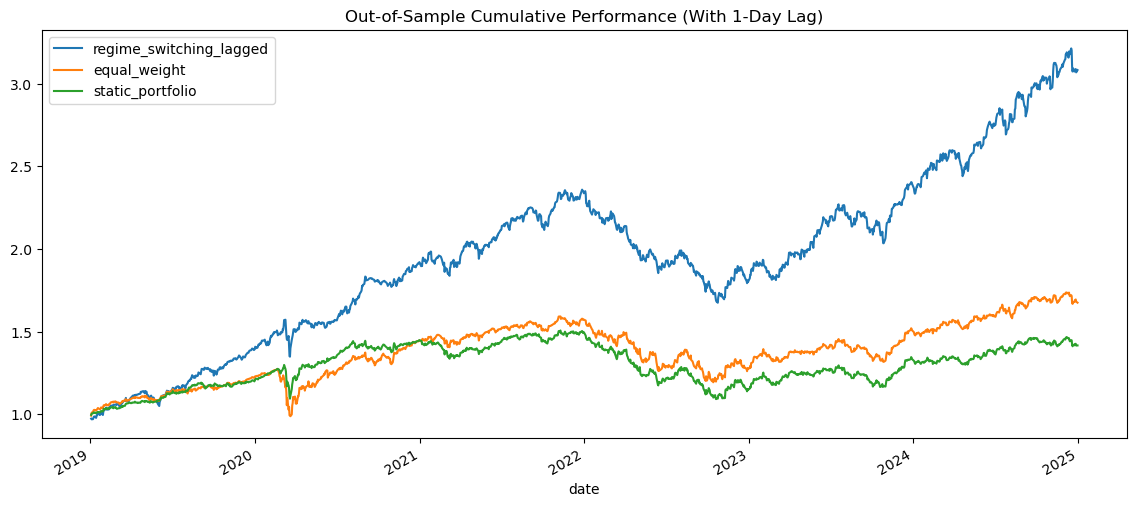

In [42]:
cumulativeDfLagged = np.exp(backtestDfLagged.cumsum())
cumulativeDfLagged.plot(figsize=(14,6), title="Out-of-Sample Cumulative Performance (With 1-Day Lag)")

In [43]:
performanceSummaryLagged = pd.DataFrame({
    "Regime Switching": portfolio_performance_summary(backtestDfLagged["regime_switching_lagged"]),
    "Equal Weight": portfolio_performance_summary(backtestDfLagged["equal_weight"]),
    "Static Portfolio": portfolio_performance_summary(backtestDfLagged["static_portfolio"])
})

performanceSummaryLagged = performanceSummaryLagged.T
performanceSummaryLagged

,mean_daily,vol_daily,annualized_return_approx,annualized_vol_approx,sharpe_approx,max_drawdown,total_return
Regime Switching,0.000746,0.008354,0.188053,0.132613,1.418062,-0.289894,2.081248
Equal Weight,0.000342,0.007978,0.086227,0.126645,0.680854,-0.250046,0.675302
Static Portfolio,0.000231,0.006633,0.058207,0.105288,0.552835,-0.275266,0.416683


## Probability-Weighted Portfolio

In [44]:
laggedProbs = outsampleState[["p_low_vol", "p_high_vol"]].shift(1).dropna()
probRetOutLagged = outsampleRet.loc[laggedProbs.index]

In [45]:
regimeProbLagged = compute_probability_weighted_returns(probRetOutLagged, laggedProbs, inRegimeMeanVarWeights0, inRegimeMeanVarWeights1)
regimeProbabilityWeightedLagged = regimeProbLagged["portfolio_return"].rename("prob_weighted")

In [46]:
backtestDf = pd.concat([regimeWeightedLagged, regimeProbabilityWeightedLagged, equallyWeightedLagged, staticWeightedLagged], axis=1).dropna()
backtestDf

,regime_switching_lagged,prob_weighted,equal_weight,static_portfolio
date,,,,
2019-01-03,-0.026209,-0.026209,-0.007903,-0.002690
2019-01-04,-0.004110,-0.004015,0.017243,0.006317
2019-01-07,0.000828,0.000829,0.006389,0.003035
2019-01-08,0.008358,0.004148,0.005421,0.002220
2019-01-09,0.006004,0.004791,0.005248,0.003093
...,...,...,...,...
2024-12-23,-0.006277,-0.001593,0.000044,-0.002234
2024-12-24,0.003501,0.007173,0.006184,0.005535
2024-12-26,0.001362,0.000561,0.002994,0.000865


<Axes: title={'center': 'Strategy Comparison'}, xlabel='date'>

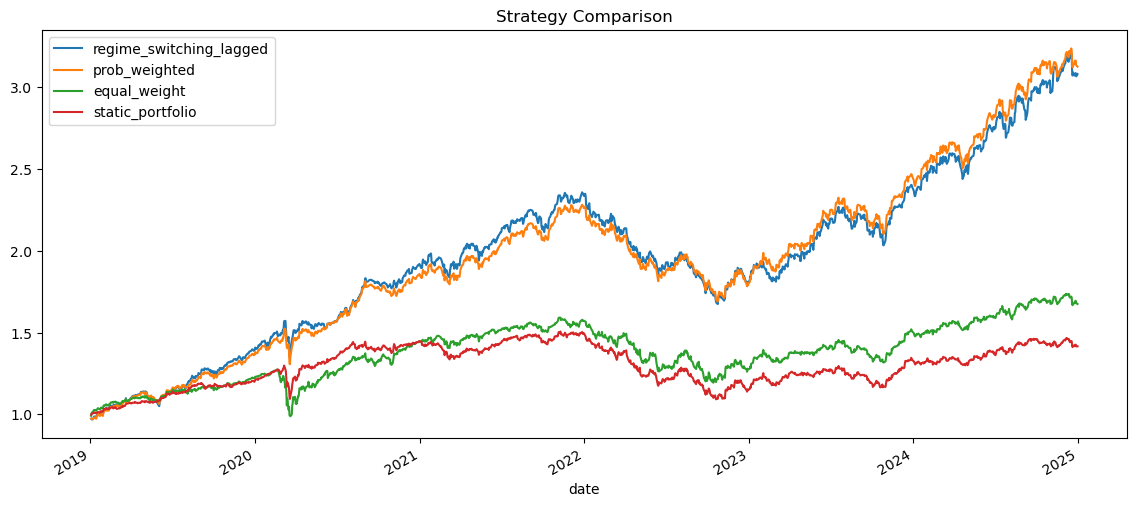

In [47]:
cum_df = np.exp(backtestDf.cumsum())
cum_df.plot(figsize=(14,6), title="Strategy Comparison")

In [48]:
performanceSummaryFull = pd.DataFrame({
    col: portfolio_performance_summary(backtestDf[col])
    for col in backtestDf.columns
}).T

performanceSummaryFull

,mean_daily,vol_daily,annualized_return_approx,annualized_vol_approx,sharpe_approx,max_drawdown,total_return
regime_switching_lagged,0.000746,0.008354,0.188053,0.132613,1.418062,-0.289894,2.081248
prob_weighted,0.000756,0.007868,0.190505,0.124904,1.525209,-0.259338,2.126786
equal_weight,0.000342,0.007978,0.086227,0.126645,0.680854,-0.250046,0.675302
static_portfolio,0.000231,0.006633,0.058207,0.105288,0.552835,-0.275266,0.416683


## Three-State HMM

In [49]:
modelThreeState, threeStateDf, scaler3 = fit_three_state_hmm(regimeRetIn)
threeStateDf, threeStateMap = relabel_three_states_by_vol(threeStateDf)
summaryThreeState = summarize_states(modelThreeState, threeStateDf)

print("\nMeans learned by model (3-State):")
print(modelThreeState.means_)

print("\nCovariances learned by model (3-State):")
print(modelThreeState.covars_)

print("\nTransition matrix:")
print(modelThreeState.transmat_)

print("\nState summary:")
print(summaryThreeState)

plot_regimes(threeStateDf, output_dir="results", plot_id="3-State")


Means learned by model (3-State):
[[-0.03410014]
 [ 0.07135263]
 [-0.18233889]]

Covariances learned by model (3-State):
[[[0.85733125]]

 [[0.15441947]]

 [[5.4649337 ]]]

Transition matrix:
[[9.57325285e-01 3.68329577e-02 5.84175700e-03]
 [3.51702808e-02 9.64829687e-01 3.17678790e-08]
 [2.30997456e-02 1.14000434e-21 9.76900254e-01]]

State summary:
   state  n_obs  fraction  mean_return  volatility  annualized_mean_approx  \
0      0   1419  0.480691     0.001120    0.005032                0.282251   
1      1   1251  0.423780    -0.000174    0.011834               -0.043939   
2      2    282  0.095528    -0.002049    0.029776               -0.516337   

   annualized_vol_approx  
0               0.079886  
1               0.187854  
2               0.472672  


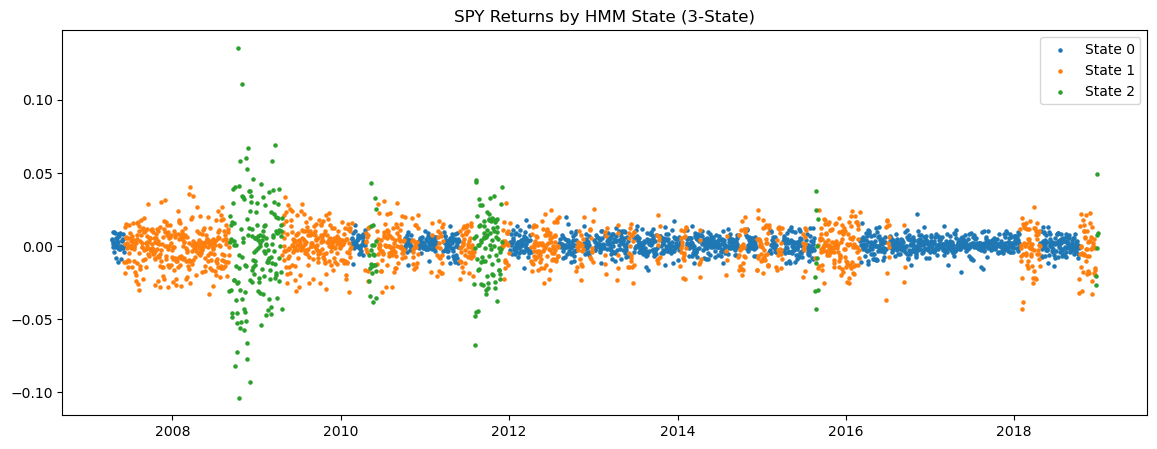

In [50]:
plt.figure(figsize=(14, 5))
for s in [0, 1, 2]:
    mask = threeStateDf["state"] == s
    plt.scatter(
        threeStateDf.index[mask],
        threeStateDf.loc[mask, "SPY_ret"],
        s=5,
        label=f"State {s}"
    )
plt.legend()
plt.title("SPY Returns by HMM State (3-State)")
plt.show()

In [51]:
regimeLabels3 = threeStateDf[["state"]].copy()
threeStateInRet = insampleRet.join(regimeLabels3, how="inner")

asset_cols = [c for c in threeStateInRet.columns if c != "state"]

lowRegimeRet = threeStateInRet.loc[threeStateInRet["state"] == 0, asset_cols]
medRegimeRet = threeStateInRet.loc[threeStateInRet["state"] == 1, asset_cols]
highRegimeRet = threeStateInRet.loc[threeStateInRet["state"] == 2, asset_cols]

In [52]:
lowRegimeMu, cov_low = lowRegimeRet.mean(), lowRegimeRet.cov()
medRegimeMu, cov_med = medRegimeRet.mean(), medRegimeRet.cov()
highRegimeMu, cov_high = highRegimeRet.mean(), highRegimeRet.cov()

In [53]:
lowRegimeWeights = solve_mean_variance_portfolio(lowRegimeMu, cov_low, risk_aversion=10.0, max_weight=0.5)
medRegimeWeights = solve_mean_variance_portfolio(medRegimeMu, cov_med, risk_aversion=10.0, max_weight=0.5)
highRegimeWeights = solve_mean_variance_portfolio(highRegimeMu, cov_high, risk_aversion=10.0, max_weight=0.5)

threeStateWeights = pd.DataFrame({
    "LowVol": lowRegimeWeights,
    "MidVol": medRegimeWeights,
    "HighVol": highRegimeWeights
})
threeStateWeights

,LowVol,MidVol,HighVol
EFA,-2.073166e-22,4.297904e-23,3.812179e-25
GLD,-2.706948e-22,9.814048e-02,1.803566e-01
HYG,-2.985870e-22,3.385473e-01,8.157068e-02
IWM,2.068645e-17,-2.741319e-23,-1.539651e-23
LQD,-3.071876e-22,2.597725e-01,1.832105e-01
QQQ,5.000000e-01,-5.859898e-24,5.486214e-02
SPY,5.000000e-01,3.546702e-23,1.273987e-23
TLT,-2.641600e-22,3.035397e-01,5.000000e-01


<Axes: title={'center': 'Portfolio Weights by Regime (Mean-Variance, 3-State)'}>

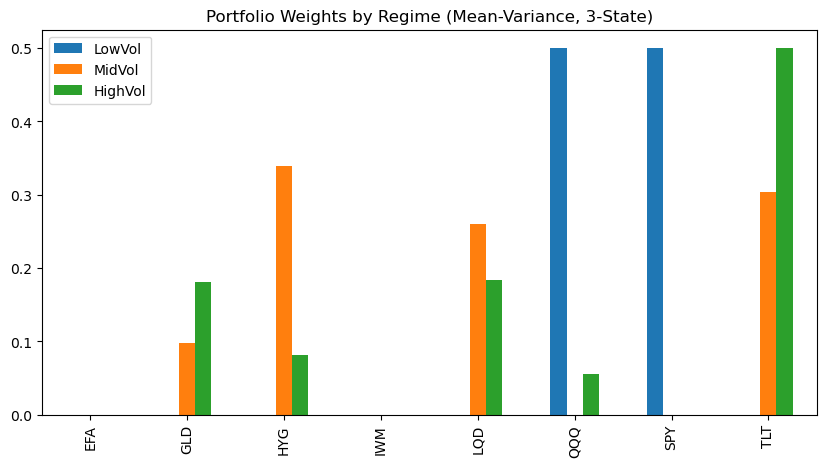

In [54]:
threeStateWeights.plot(kind="bar", figsize=(10, 5), title="Portfolio Weights by Regime (Mean-Variance, 3-State)")

In [62]:
outsampleThreeStatesRaw = classify_outsample_regimes_nstate(modelThreeState, scaler3, outsampleRet[["SPY"]], n_states=3)
outsampleThreeStates = apply_three_state_mapping(outsampleThreeStatesRaw, threeStateMap)

In [63]:
threeStateLagged = outsampleThreeStates["state"].shift(1).dropna()
laggedThreeStateOut = outsampleRet.loc[threeStateLagged.index]

In [67]:
regimeWeightedThreeState = compute_three_state_weighted_returns(
    laggedThreeStateOut,
    threeStateLagged,
    lowRegimeWeights,
    medRegimeWeights,
    highRegimeWeights
)
regimeWeightedThreeState = regimeWeightedThreeState["portfolio_return"].rename("regime_switching_3state")

In [68]:
laggedThreeStateProb = outsampleThreeStates[["p_low_vol", "p_mid_vol", "p_high_vol"]].shift(1).dropna()
probRetOutLagged3 = outsampleRet.loc[laggedThreeStateProb.index]

probWeightedThreeState = compute_three_state_probability_weighted_returns(
    probRetOutLagged3,
    laggedThreeStateProb,
    lowRegimeWeights,
    medRegimeWeights,
    highRegimeWeights
)

probWeightedThreeState = probWeightedThreeState["portfolio_return"].rename("prob_weighted_3state")

In [73]:
comparisonDf = pd.concat([
    regimeWeightedLagged.rename("regime_switching_2state"),
    regimeProbabilityWeightedLagged.rename("prob_weighted_2state"),
    regimeWeightedThreeState,
    probWeightedThreeState,
    equallyWeightedLagged.rename("equal_weight"),
    staticWeightedLagged.rename("static_portfolio")
], axis=1).dropna()

In [74]:
performanceComparison = pd.DataFrame({
    col: portfolio_performance_summary(comparisonDf[col])
    for col in comparisonDf.columns
}).T

performanceComparison

,mean_daily,vol_daily,annualized_return_approx,annualized_vol_approx,sharpe_approx,max_drawdown,total_return
regime_switching_2state,0.000746,0.008354,0.188053,0.132613,1.418062,-0.289894,2.081248
prob_weighted_2state,0.000756,0.007868,0.190505,0.124904,1.525209,-0.259338,2.126786
regime_switching_3state,0.000561,0.007020,0.141314,0.111443,1.268034,-0.254902,1.329467
prob_weighted_3state,0.000622,0.006586,0.156762,0.104547,1.499440,-0.253186,1.555087
equal_weight,0.000342,0.007978,0.086227,0.126645,0.680854,-0.250046,0.675302
static_portfolio,0.000231,0.006633,0.058207,0.105288,0.552835,-0.275266,0.416683


<Axes: title={'center': '2-State vs 3-State Comparison'}, xlabel='date'>

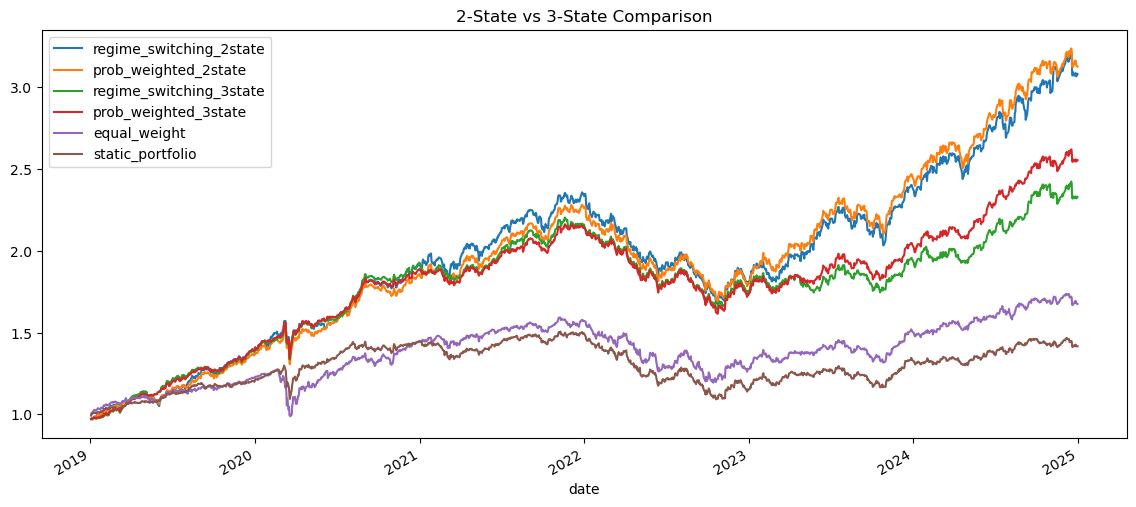

In [75]:
np.exp(comparisonDf.cumsum()).plot(figsize=(14,6), title="2-State vs 3-State Comparison")